In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# 2 метра
L_ = 2.

a_ = 0.6

# 6000 Н
P_ = 6000.0

h_ = 0.1
b_ = 0.1

# 𝐸 = 200 ГПа
E_ = 200000000000.0

# количество точек
Q = 10000

# (f(x) = coef_ * M(x))
coef_ = (12.)/(E_*b_*(h_**3))

def is_between_0_a(x):
    return x >= 0 and x < a_

def is_between_a__L_minus_a(x):
    return x >= a_ and x < (L_ - a_)

def is_between_L_minus_a__L(x):
    return x >= (L_ - a_) and x <= L_

def getM(x):
    if (is_between_0_a(x)):
        return P_*x
    if (is_between_a__L_minus_a(x)):
        return P_*a_
    if (is_between_L_minus_a__L(x)):
        return P_*(L_ - x)
    else:
        raise ValueError("Некорректное значение! x = " + x)


# c=3600000
# def u_actual(x):
    # if x < L_/2:
      # return c_*((1/12)*(x**3)-(1/16)*(L_**2)*x)
      # 300000*(x**3)-900000*x
      # -2368
    # else:
     # return c_*((1/4)*L_*(x**2)-(1/12)*(x**3)-(3/16)*(L_**2)*x+(1/48)*(L_**3))
      # 1800000*(x**2)-300000*(x**3)-2700000*x+600000

# def f(x):
    # if x < L_/2:
      # return c_*(x/2)
    # else:
      # return c_*((L_-x)/2)

# точное решение
def u_actual(x):
    coef_u = coef_ * (P_ / 6)

    if (is_between_0_a(x)):
        u_exact = coef_u * ((x**3) - (3 * (L_ - a_) * a_ * x))
    elif (is_between_a__L_minus_a(x)):
        u_exact = coef_u * (3*a_*(x**2) - 3*L_*a_*x + a_**3)
    elif (is_between_L_minus_a__L(x)):
        # coef before x
        coef_a1 = 3*(-(L_**2) + L_*a_ - (a_**2))
        # coef before x^0
        coef_a0 = L_**3 - 3*L_*L_*a_ + 3*L_*a_*a_;
        u_exact = coef_u * (-(x**3) + 3*L_*(x**2) + coef_a1 * x + coef_a0)
    else:
        raise ValueError("Некорректное значение! x = " + x)

    return u_exact;

# правая часть
def f(x):
    # (f(x) = coef_ * M(x))
    m_x = getM(x)
    return coef_ * m_x

def find_node(x, x_nodes):
    for i in range(1, len(x_nodes)):
        if x < x_nodes[i]:
            return i-1
    return len(x_nodes)-2


def solve(N):
    x_nodes = np.linspace(0, L_, N+1)
    cell_length = x_nodes[1] - x_nodes[0]

    # формируем матрицу жёсткости
    K = np.zeros((N+1, N+1))
    for i in range(N):
        K[i][i:i+2] += [1, -1]
        K[i+1][i:i+2] += [-1, 1]
    if N == 5:
        print("x_nodes:")
        print(x_nodes)
    K /= cell_length
    K[0][1], K[-1][-2] = 0, 0
    K[0][0], K[-1][-1] = 1, 1
    P = np.zeros((N+1, N+1))
    for i in range(N):
        P[i][i:i+2] += [2, 1]
        P[i+1][i:i+2] += [1, 2]

    P *= -cell_length / 6
    P[0][0:2] = [0, 0]
    P[-1][-2:] = [0, 0]
    if N == 5:
        print("f(0.4):")
        print(f(0.4))
        
    if N == 5:
        print("P:")
        print(P)
        
    P = np.dot(P, [f(interval) for interval in x_nodes])
    # if N == 5:
    #     print("P:")
    #     print(P)

    u_coeffs = np.linalg.solve(K, P)

    if N == 5:
        print("u_coeffs:")
        print(u_coeffs)

    return x_nodes, u_coeffs, K

# прибл. решение
def u_approx(x, x_nodes, u_coeffs):
    dx = x_nodes[1] - x_nodes[0]
    output = np.zeros(len(x))
    for i in range(len(x)):
        k = find_node(x[i], x_nodes)
        a0 = (u_coeffs[k] * x_nodes[k+1] - u_coeffs[k+1] * x_nodes[k])/dx
        a1 = (u_coeffs[k] - u_coeffs[k+1])/-dx
        output[i] = a0 + a1*x[i]  # (7)
    return output


def relative_errors(x_nodes, u_coeffs):
    x = np.linspace(0, L_, Q)
    
    u_h = np.array(u_approx(x, x_nodes, u_coeffs))
    u_ex = np.array([u_actual(i) for i in x])

    # L-infinity - norm
    up_max = np.max(np.abs(u_ex - u_h))
    low_max = np.max(np.abs(u_ex))
    Er = up_max / low_max

    # approximate L2-norm 
    dx = x[1] - x[0]
    up_sum = np.sum((u_ex - u_h)**2*dx)
    low_sum = np.sum(u_ex**2*dx)
    ErL2 = np.sqrt(up_sum/low_sum)

    return Er, ErL2

x_nodes:
[0.  0.4 0.8 1.2 1.6 2. ]
f(0.4):
0.0014399999999999997
P:
[[ 0.          0.         -0.         -0.         -0.         -0.        ]
 [-0.06666667 -0.26666667 -0.06666667 -0.         -0.         -0.        ]
 [-0.         -0.06666667 -0.26666667 -0.06666667 -0.         -0.        ]
 [-0.         -0.         -0.06666667 -0.26666667 -0.06666667 -0.        ]
 [-0.         -0.         -0.         -0.06666667 -0.26666667 -0.06666667]
 [-0.         -0.         -0.         -0.          0.          0.        ]]
u_coeffs:
[-0.        -0.0005376 -0.000864  -0.000864  -0.0005376  0.       ]
матрица жесткости K:
[[ 1.   0.   0.   0.   0.   0. ]
 [-2.5  5.  -2.5  0.   0.   0. ]
 [ 0.  -2.5  5.  -2.5  0.   0. ]
 [ 0.   0.  -2.5  5.  -2.5  0. ]
 [ 0.   0.   0.  -2.5  5.  -2.5]
 [ 0.   0.   0.   0.   0.   1. ]]
5 0.09090908057644553 0.08095295466045767
10 0.011363630923499743 0.008990297186232475
20 0.0028409043211009314 0.002255060408772515
40 0.0007102228409955869 0.000564232013970381
80 0

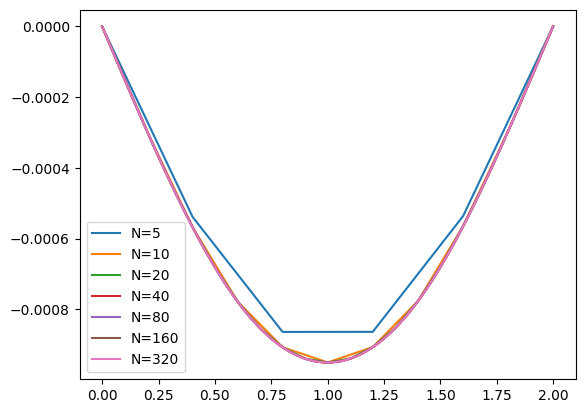

In [ ]:
x = np.linspace(0, L_, Q)
plt.plot(x, [u_actual(i) for i in x], 'r')
prevErL2=1
prevErL_infinity=1
lines = []
for N in [5, 10, 20, 40, 80, 160, 320]:
    x_nodes, u_coeffs, K = solve(N)
    ErL_infinity, ErL2 = relative_errors(x_nodes, u_coeffs)
    if N != 2:
        plt.plot(x, u_approx(x, x_nodes, u_coeffs), label=f'N={N}')
        R_L2 = np.log2(prevErL2/ErL2)
        R_L_infinity = np.log2(prevErL_infinity/ErL_infinity)
        lines.append(f"{N}\t"
                    f"{ErL_infinity:.2e}\t"
                    f"{R_L_infinity:.2e}\t"
                    f"{ErL2:.2e}\t"
                    f"{R_L2:.2e}\t"
                    f"{np.linalg.cond(K):.2e}\n")
    if N == 5:
        print("матрица жесткости K:")
        print(K)
    print(N, ErL_infinity, ErL2)
    prevErL2 = ErL2

for line in ['N\tEr\torder\tErL2\torder\tcond\n'] + lines:
    print(line)
plt.legend()
plt.show()